# Imports

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Code

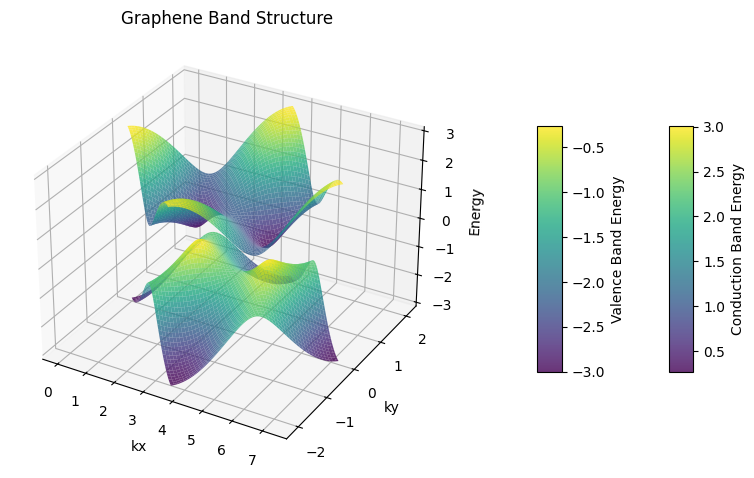

0.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Ebar = 0
Delta = 0.5
tperp = 0.12

# FBZ Resolution
L = 150

# Reciprocal lattice vectors
b1 = 4 * np.pi / 3 * np.array([np.sqrt(3)/2, 1/2])
b2 = 4 * np.pi / 3 * np.array([-np.sqrt(3)/2, 1/2]) * (-1)

# Create the meshgrid for k-vector indexes
m1 = np.linspace(0, 1, L)
m2 = np.linspace(0, 1, L)
M1, M2 = np.meshgrid(m1, m2)

# Map the fractional meshgrid to Cartesian kx, ky space
mesh_kx = M1 * b1[0] + M2 * b2[0]
mesh_ky = M1 * b1[1] + M2 * b2[1]

# Calculate the function f^2
f_k_squared = 3 + 2 * np.cos(np.sqrt(3) * mesh_kx) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx) * np.cos(3/2 * mesh_ky)

# Compute the bands
E_conduct = Ebar + 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)
E_valence = Ebar - 0.5 * np.sqrt(Delta**2 + 4 * f_k_squared)

# Plot Surfaces
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))

surf_c = ax.plot_surface(mesh_kx, mesh_ky, E_conduct, cmap='viridis', linewidth=0, antialiased=True, alpha=0.8)
surf_v = ax.plot_surface(mesh_kx, mesh_ky, E_valence, cmap='viridis', linewidth=0, antialiased=True, alpha=0.8)

fig.colorbar(surf_c, shrink=0.4, aspect=10, pad=0.05, label="Conduction Band Energy")
fig.colorbar(surf_v, shrink=0.4, aspect=10, pad=0.15, label="Valence Band Energy")
ax.set_xlabel('kx')
ax.set_ylabel('ky')
ax.set_zlabel('Energy')
ax.set_title('Graphene Band Structure')

plt.show()


# Plot cut along ky = 0
mask = np.argwhere(mesh_ky == np.min(np.abs(mesh_ky)))
f_k_squared = np.array([3 + 2 * np.cos(np.sqrt(3) * mesh_kx[item]) + 4 * np.cos(np.sqrt(3)/2 * mesh_kx[item]) * np.cos(3/2 * mesh_ky[item]) for item in mask])